# Homework 4

This file contains code to solve problems on Homework 4 issued by Akil Narayan.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

SEED = 0

In [5]:
rng = np.random.default_rng(SEED)

# Load data
faces = fetch_olivetti_faces(shuffle=True, random_state=SEED)

images = faces.images          # shape: (400, 64, 64)
labels = faces.target          # subject labels 0,...,39
n_images, h, w = images.shape

Truncated SVD of faces

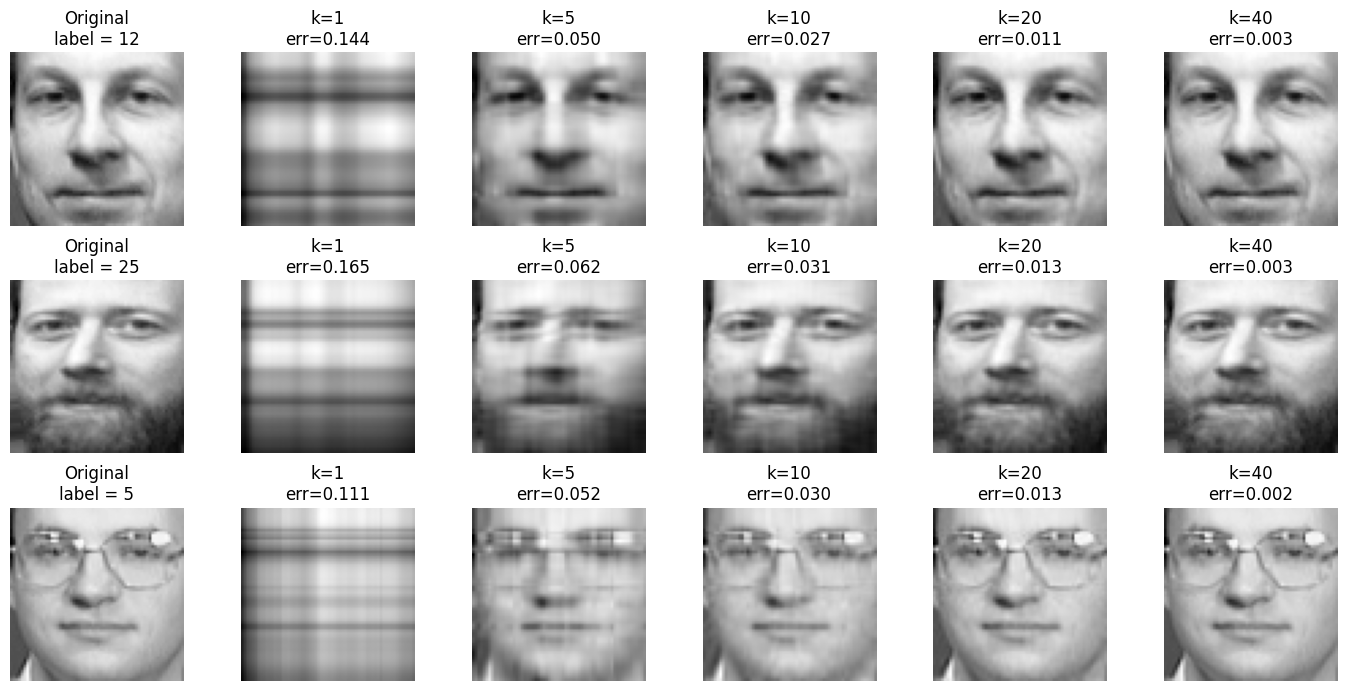

In [6]:
chosen_idx = rng.choice(n_images, size=3, replace=False)
k_svd = [1, 5, 10, 20, 40]

def truncated_svd(A, k):
    """Return rank-k SVD approximation of image matrix A."""
    U, s, VT = np.linalg.svd(A, full_matrices=False)
    return (U[:, :k] * s[:k]) @ VT[:k, :]

def relative_frobenius_error(A, A_k):
    return np.linalg.norm(A - A_k, "fro") / np.linalg.norm(A, "fro")

# Plot original images and their low-rank approximations
fig, axes = plt.subplots(len(chosen_idx), len(k_svd) + 1,
                         figsize=(14, 7))

for row, idx in enumerate(chosen_idx):
    A = images[idx]

    axes[row, 0].imshow(A, cmap="gray")
    axes[row, 0].set_title(f"Original\nlabel = {labels[idx]}")
    axes[row, 0].axis("off")

    for col, k in enumerate(k_svd, start=1):
        A_k = truncated_svd(A, k)
        err = relative_frobenius_error(A, A_k)

        axes[row, col].imshow(A_k, cmap="gray")
        axes[row, col].set_title(f"k={k}\nerr={err:.3f}")
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()